# 05 XGBoost Comparison



## Objetivo

En este cuaderno se desarrollará un modelo basado en XGBoost para predecir una de las variables objetivo del cultivo de caña de azúcar a partir de información histórica del Ingenio Providencia. Dependiendo del dataset trabajado, el objetivo será estimar el rendimiento del cultivo medido en Toneladas de Caña por Hectárea (TCH) o la calidad de la caña medida a través del porcentaje de sacarosa (%Sac.Caña).

El propósito es evaluar si un modelo avanzado como XGBoost puede capturar de mejor manera las relaciones no lineales y las interacciones complejas entre variables agronómicas, climáticas y de manejo del cultivo, en comparación con modelos más simples. Además, se busca identificar cuáles variables son más influyentes en la predicción, conectando estos resultados con el contexto del negocio y del proceso productivo de la caña de azúcar.

## Justificacion de la eleccion del modelo XGBoost

XGBoost fue seleccionado porque puede modelar relaciones no lineales e interacciones complejas entre variables agronómicas, climáticas y de manejo del cultivo, algo que modelos más simples como la regresión lineal o logística no siempre logran capturar adecuadamente. Además, suele presentar un alto desempeño en datos tabulares y permite analizar la importancia de las variables, lo que resulta útil para interpretar qué factores influyen más en la predicción de TCH, %Sac.Caña o sus clases de desempeño.

## Cargamos librerias

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold,StratifiedKFold
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)



## Carga de datasets

En esta sección se cargan los cuatro datasets finales previamente depurados y preparados para el modelado. Estos corresponden a los dos problemas de regresión (TCH y %Sac.Caña) y a los dos problemas de clasificación (niveles de TCH y niveles de sacarosa). De esta manera, se mantiene una organización clara del trabajo y se facilita el entrenamiento independiente de cada modelo según su objetivo.

In [3]:
sys.path.append(os.path.abspath('..'))


# Rutas de los datasets procesados
REG_TCH_PATH = '../data/processed/datos_limpios_regresion_tch.csv'
REG_SAC_PATH = '../data/processed/datos_limpios_regresion_sacarosa.csv'
CLF_TCH_PATH = '../data/processed/datos_limpios_clasificacion_tch.csv'
CLF_SAC_PATH = '../data/processed/datos_limpios_clasificacion_sacarosa.csv'

# Cargar datasets
df_reg_tch = pd.read_csv(REG_TCH_PATH)
df_reg_sac = pd.read_csv(REG_SAC_PATH)
df_clf_tch = pd.read_csv(CLF_TCH_PATH)
df_clf_sac = pd.read_csv(CLF_SAC_PATH)

# Verificación rápida
print("Regresión TCH:", df_reg_tch.shape)
print("Regresión Sacarosa:", df_reg_sac.shape)
print("Clasificación TCH:", df_clf_tch.shape)
print("Clasificación Sacarosa:", df_clf_sac.shape)


Regresión TCH: (20733, 19)
Regresión Sacarosa: (20578, 19)
Clasificación TCH: (2187, 9)
Clasificación Sacarosa: (2187, 9)


## XGBOOST para dataset de regresion para predecir la varibale tch

### Division de variables predectivas y objetivos

La variable objetivo del modelo será TCH, dado que representa las toneladas de caña por hectárea y constituye una medida directa del rendimiento productivo del cultivo. Como variables predictoras se utilizarán las demás columnas disponibles en el dataset, las cuales contienen información agronómica, climática y de manejo del lote.

Siguiendo las recomendaciones de validación rigurosa, el dataset se dividirá en un conjunto de entrenamiento (80 %) y un conjunto de prueba (20 %). El conjunto de entrenamiento se utilizará para ajustar el modelo y realizar validación cruzada, mientras que el conjunto de prueba quedará reservado para la evaluación final del desempeño.

In [4]:
# Definimos las variable objetivo y predictores

X = df_reg_tch.drop(columns=['TCH'], errors='ignore')
y = df_reg_tch['TCH']

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16586, 18)
X_test : (4147, 18)
y_train: (16586,)
y_test : (4147,)


## Validacion cruzada y ajuste de hiperparametros

Para el modelo XGBoost se definió objective='reg:squarederror' debido a que el problema abordado corresponde a una tarea de regresión, en la que se busca predecir una variable continua como TCH. Esta función objetivo indica que el modelo optimizará el error cuadrático, penalizando con mayor fuerza las predicciones que se alejan mucho del valor real.

En el proceso de ajuste se seleccionaron los hiperparámetros n_estimators, max_depth, learning_rate, subsample y colsample_bytree, ya que son los que más influyen en la capacidad de aprendizaje, complejidad y generalización del modelo. En particular, n_estimators controla la cantidad de árboles, max_depth la profundidad de cada árbol, learning_rate la velocidad con la que el modelo corrige sus errores, y subsample junto con colsample_bytree introducen aleatoriedad al usar subconjuntos de registros y variables, ayudando a controlar el sobreajuste.

Para seleccionar la mejor combinación de hiperparámetros se utilizó GridSearchCV con validación cruzada. Como criterio de evaluación se empleó scoring='neg_root_mean_squared_error', es decir, el RMSE expresado en forma negativa. Esta métrica permite medir qué tan cerca están las predicciones de los valores reales en las mismas unidades de la variable objetivo. La forma negativa se debe a que GridSearchCV está diseñado para maximizar el score, por lo que sklearn invierte el signo de las métricas de error. De esta manera, el modelo elegido corresponde a aquel que presenta el menor error de predicción durante la validación cruzada.

In [5]:
# Definir modelo base
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Espacio de hiperparámetros
param_grid = {
    #numero de arboles a construir
    'n_estimators': [100, 200,300],
    #profundidad máxima de cada árbol
    'max_depth': [3, 5, 7],
    #tasa de aprendizaje para actualizar los pesos de los árboles
    'learning_rate': [0.01, 0.05, 0.1],
    #número mínimo de muestras requeridas para dividir un nodo
    'subsample': [0.6,0.8, 1.0],
    #proporción de características a considerar en cada división
    'colsample_bytree': [0.6,0.8, 1.0]
}

# Búsqueda con validación cruzada
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_search.best_params_)

print("\nMejor score CV (RMSE negativo):")
print(grid_search.best_score_)

Fitting 10 folds for each of 243 candidates, totalling 2430 fits
Mejores parámetros:
{'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}

Mejor score CV (RMSE negativo):
-24.42216785102902


### Entrenamiento final y evaluacion en el conjunto de pruebas

Una vez finalizada la búsqueda de hiperparámetros mediante validación cruzada, se selecciona el mejor modelo encontrado y se utiliza para generar predicciones sobre el conjunto de prueba. Esto permite evaluar su capacidad de generalización con métricas de regresión como MAE, RMSE y R².


Evaluación del modelo en test:
MAE : 17.7428
RMSE: 23.7956
R²  : 0.4620


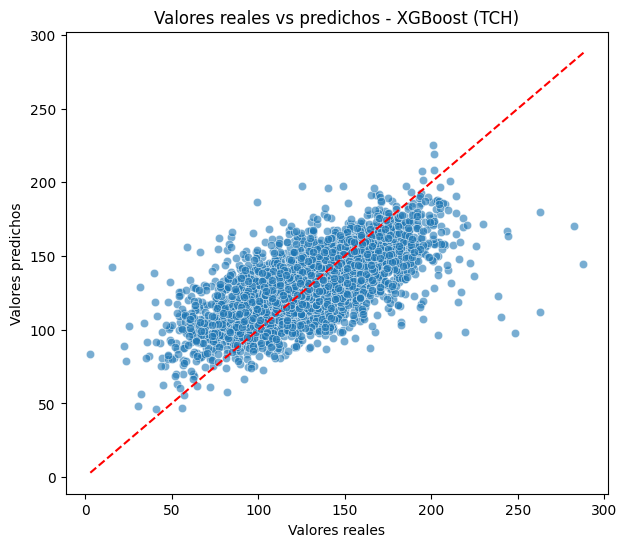

In [6]:
# Mejor modelo encontrado por GridSearch
best_model = grid_search.best_estimator_

# Predicciones sobre el conjunto de prueba
y_pred = best_model.predict(X_test)

# Métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Evaluación del modelo en test:")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# Gráfico de valores reales vs predichos
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Línea ideal y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.title('Valores reales vs predichos - XGBoost (TCH)')
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.show()

### Importancia de variables

Como parte de la interpretabilidad del modelo, se analiza la importancia de las variables predictoras en XGBoost. Esto permite identificar cuáles factores tuvieron mayor influencia en la predicción de TCH y relacionar esos resultados con el contexto agronómico del cultivo de caña de azúcar.

                  Variable  Importancia
2                 Variedad     0.111769
3             Edad Ult Cos     0.095364
1                  Dist Km     0.082424
16            Luvias 9 -FC     0.061154
9                  T.Corte     0.057578
5          Dosis Madurante     0.051429
8               Tipo Quema     0.049502
4                  Cultivo     0.049401
15    Lluvias seis a nueve     0.048264
7                    Vejez     0.047929
13            Lluvias 0 -3     0.046736
6             Semanas mad.     0.046456
14     Lluvias tres a seis     0.045706
11             DDUlt.Riego     0.044286
10                M3 Riego     0.043494
17         %Infest.Diatrea     0.040854
0                Area Neta     0.039839
12  Lluvias (2 Meses Ant.)     0.037815


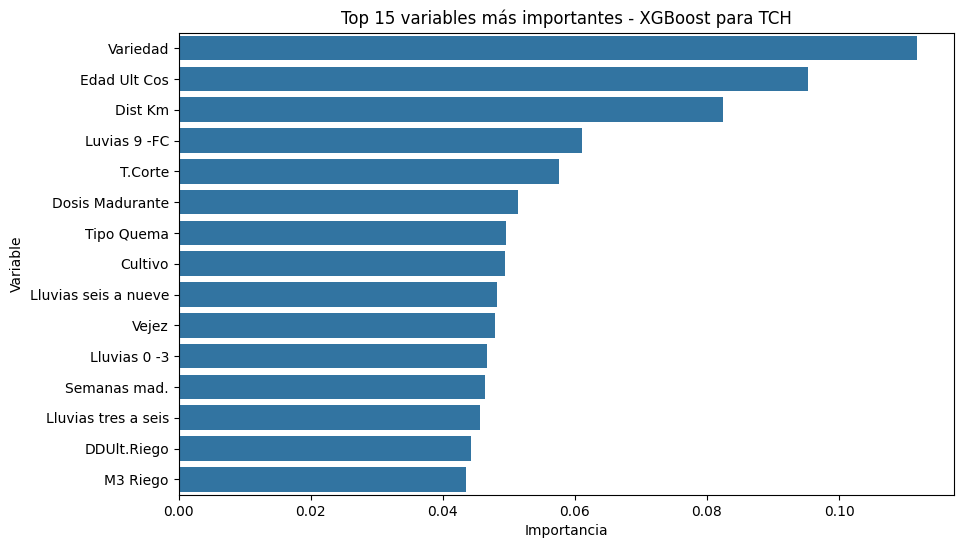

In [7]:
# Importancia de variables
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': best_model.feature_importances_
})

# Ordenar de mayor a menor
importancias = importancias.sort_values(by='Importancia', ascending=False)

print(importancias)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias.head(15), x='Importancia', y='Variable')
plt.title('Top 15 variables más importantes - XGBoost para TCH')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

### Interpretacion de resultados

El modelo XGBoost para regresión de TCH obtuvo un MAE de 17.74, un RMSE de 23.80 y un R² de 0.4620 sobre el conjunto de prueba. Estos resultados indican que el modelo logra capturar una parte importante de la variabilidad del rendimiento, aunque todavía existe un margen de error considerable. En promedio, las predicciones se desvían alrededor de 17.74 toneladas por hectárea respecto al valor real, mientras que el RMSE sugiere la presencia de algunos errores más grandes en ciertos casos. Por su parte, el valor de R² muestra que el modelo explica aproximadamente el 46.2 % de la variabilidad de TCH, lo que puede considerarse un desempeño moderado dentro de un problema agrícola, donde intervienen múltiples factores agronómicos, climáticos y de manejo.

## XGBOOST para dataset de regresion para predecir la varibale Sacarosa

### Division de variables predectivas y objetivo

Se realiza el mismo proceso que para el anterior dataset la unica diferencia es que para este dataset la varibale objetivo es sacarosa

In [8]:
X_sac = df_reg_sac.drop(columns=['%Sac.Caña'], errors='ignore')
y_sac = df_reg_sac['%Sac.Caña']

X_train_sac, X_test_sac, y_train_sac, y_test_sac = train_test_split(
    X_sac, y_sac,
    test_size=0.2,
    random_state=42
)

print("X_train_sac:", X_train_sac.shape)
print("X_test_sac :", X_test_sac.shape)
print("y_train_sac:", y_train_sac.shape)
print("y_test_sac :", y_test_sac.shape)

X_train_sac: (16462, 18)
X_test_sac : (4116, 18)
y_train_sac: (16462,)
y_test_sac : (4116,)


### Validacion cruzada y busqueda de los mejores hiperparametros

Realizamos el mismo proceso que en el anterior dataset

In [9]:
# Definir modelo base
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Espacio de hiperparámetros
param_grid = {
    #numero de arboles a construir
    'n_estimators': [100, 200,300],
    #profundidad máxima de cada árbol
    'max_depth': [3, 5, 7],
    #tasa de aprendizaje para actualizar los pesos de los árboles
    'learning_rate': [0.01, 0.05, 0.1],
    #número mínimo de muestras requeridas para dividir un nodo
    'subsample': [0.6,0.8, 1.0],
    #proporción de características a considerar en cada división
    'colsample_bytree': [0.6,0.8, 1.0]
}

# Búsqueda con validación cruzada
grid_search_sac = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_sac.fit(X_train_sac, y_train_sac)

print("Mejores parámetros:")
print(grid_search_sac.best_params_)

print("\nMejor score CV (RMSE negativo):")
print(grid_search_sac.best_score_)

Fitting 10 folds for each of 243 candidates, totalling 2430 fits
Mejores parámetros:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}

Mejor score CV (RMSE negativo):
-0.8771587355392917


### Entrenamiento y evaluacion

Con el modelo ya entrenado evaluamos 

Evaluación del modelo en test:
MAE : 0.6787
RMSE: 0.8792
R²  : 0.4184


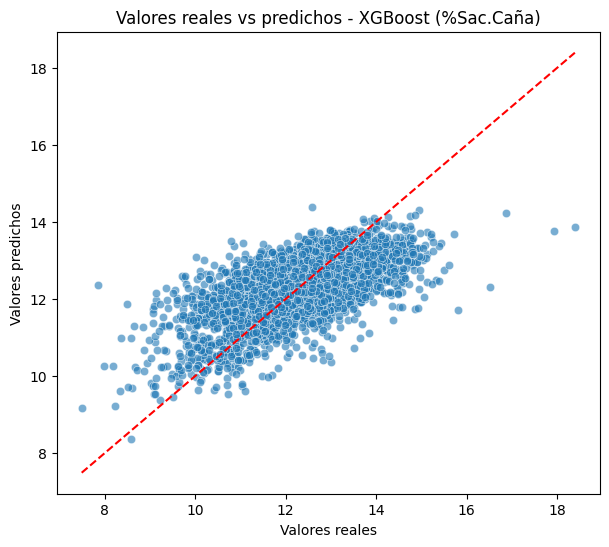

In [10]:
# Mejor modelo encontrado por GridSearch
best_model_sac = grid_search_sac.best_estimator_

# Predicciones sobre el conjunto de prueba
y_pred_sac = best_model_sac.predict(X_test_sac)

# Métricas de evaluación
mae = mean_absolute_error(y_test_sac, y_pred_sac)
rmse = np.sqrt(mean_squared_error(y_test_sac, y_pred_sac))
r2 = r2_score(y_test_sac, y_pred_sac)

print("Evaluación del modelo en test:")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# Gráfico de valores reales vs predichos
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test_sac, y=y_pred_sac, alpha=0.6)

# Línea ideal y = x
min_val = min(y_test_sac.min(), y_pred_sac.min())
max_val = max(y_test_sac.max(), y_pred_sac.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.title('Valores reales vs predichos - XGBoost (%Sac.Caña)')
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.show()

### Importancia de Variables

En el análisis de importancia de variables, Cultivo apareció como el predictor más influyente con una diferencia amplia frente al resto, lo que sugiere que el tipo de manejo del cultivo tiene una fuerte asociación con el porcentaje de sacarosa. También destacaron Dosis Madurante, Semanas mad., T.Corte, Variedad y algunas variables de lluvia, lo cual resulta consistente con el contexto agronómico, ya que la calidad de la caña depende en gran medida del proceso de maduración, de las condiciones climáticas previas a la cosecha y del material sembrado.

                  Variable  Importancia
4                  Cultivo     0.580252
5          Dosis Madurante     0.093073
6             Semanas mad.     0.035872
9                  T.Corte     0.033860
2                 Variedad     0.031853
12  Lluvias (2 Meses Ant.)     0.030990
3             Edad Ult Cos     0.023828
16            Luvias 9 -FC     0.022199
8               Tipo Quema     0.020839
1                  Dist Km     0.017225
15    Lluvias seis a nueve     0.016227
14     Lluvias tres a seis     0.015101
13            Lluvias 0 -3     0.015040
11             DDUlt.Riego     0.013957
7                    Vejez     0.013296
10                M3 Riego     0.013127
17         %Infest.Diatrea     0.011847
0                Area Neta     0.011413


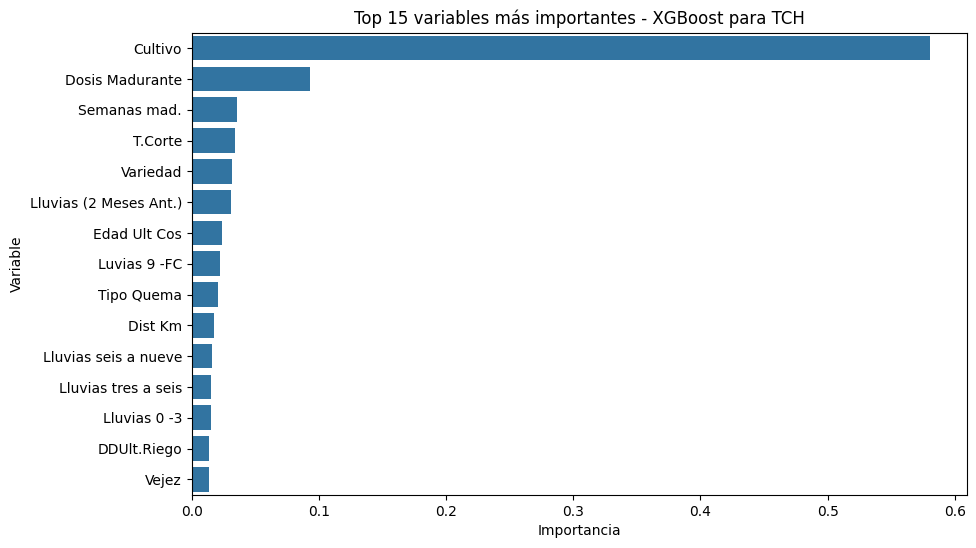

In [11]:
# Importancia de variables
importancias = pd.DataFrame({
    'Variable': X_train_sac.columns,
    'Importancia': best_model_sac.feature_importances_
})

# Ordenar de mayor a menor
importancias = importancias.sort_values(by='Importancia', ascending=False)

print(importancias)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias.head(15), x='Importancia', y='Variable')
plt.title('Top 15 variables más importantes - XGBoost para TCH')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

### Interpretacion de resultados

En conjunto, el modelo XGBoost mostró un desempeño aceptable para la predicción de %Sac.Caña, capturando patrones relevantes en variables de manejo, maduración, clima y material vegetal. Aunque la capacidad explicativa del modelo fue moderada, los resultados muestran que XGBoost es una alternativa válida para este problema. Además, la fuerte importancia de Cultivo sugiere que el tipo de sistema productivo desempeña un papel central en la estimación de la calidad de la caña, aspecto que merece ser considerado con especial atención en la interpretación de los resultados.

### Conclusion de regresion en tch y sacarosa

Al comparar ambos modelos de regresión, el de TCH presentó un desempeño ligeramente superior en términos de R², lo que indica una mayor capacidad para explicar la variabilidad del rendimiento. Sin embargo, el modelo de %Sac.Caña también mostró un comportamiento aceptable, especialmente si se considera que su error promedio fue menor a una unidad de sacarosa. En conjunto, esto sugiere que el rendimiento del cultivo fue un poco más predecible con las variables disponibles que la calidad medida en sacarosa, aunque ambos problemas mantuvieron una naturaleza multifactorial y compleja.

### XGBOOST para dataset de clasificacion para predecir la varibale TCH

### Division de variables predictoras y objetivos

Realizamos el mismo procedimiento que en los anteriores datasets

In [12]:
X_clf_tch = df_clf_tch.drop(columns=['Clase_TCH'], errors='ignore')
y_clf_tch = df_clf_tch['Clase_TCH']

X_train_tch, X_test_tch, y_train_tch, y_test_tch = train_test_split(
    X_clf_tch, y_clf_tch,
    test_size=0.2,
    random_state=42
)

print("X_train_tch:", X_train_tch.shape)
print("X_test_tch :", X_test_tch.shape)
print("y_train_tch:", y_train_tch.shape)
print("y_test_tch :", y_test_tch.shape)

X_train_tch: (1749, 8)
X_test_tch : (438, 8)
y_train_tch: (1749,)
y_test_tch : (438,)


### Validacion cruzada y busqueda de hiperparametros

Para la etapa de clasificación fue necesario ajustar la configuración utilizada previamente en regresión. En lugar de emplear XGBRegressor, se utilizó XGBClassifier, ya que ahora el objetivo no es predecir un valor continuo sino asignar cada registro a una clase (Bajo, Medio o Alto). Asimismo, la función objetivo cambió de una orientada a regresión (reg:squarederror) a una orientada a clasificación multiclase (multi:softprob), permitiendo al modelo estimar probabilidades para cada categoría. También se reemplazó KFold por StratifiedKFold, con el fin de conservar la proporción de clases en cada partición de la validación cruzada. Finalmente, la métrica de evaluación dejó de basarse en error de regresión y pasó a una métrica de clasificación, como f1_weighted, más adecuada para medir el desempeño del modelo al distinguir entre clases.

In [13]:
# Modelo base para clasificación
xgb_base_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

# Validación cruzada estratificada
cv_clf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Espacio de hiperparámetros
param_grid_clf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Búsqueda con validación cruzada
grid_search_clf = GridSearchCV(
    estimator=xgb_base_clf,
    param_grid=param_grid_clf,
    cv=cv_clf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_clf.fit(X_train_tch, y_train_tch)

print("Mejores parámetros:")
print(grid_search_clf.best_params_)

print("\nMejor score CV:")
print(grid_search_clf.best_score_)

Fitting 10 folds for each of 243 candidates, totalling 2430 fits
Mejores parámetros:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}

Mejor score CV:
0.48631755742985694


### Evaluacion del modelo

In [14]:
# Predicciones
y_pred_clf = grid_search_clf.best_estimator_.predict(X_test_tch)

# Métricas
accuracy = accuracy_score(y_test_tch, y_pred_clf)
recall_macro = recall_score(y_test_tch, y_pred_clf, average='macro')
f1_macro = f1_score(y_test_tch, y_pred_clf, average='macro')
kappa = cohen_kappa_score(y_test_tch, y_pred_clf)

print('--- REPORTE DE RESULTADOS ---')
print(f'Accuracy         : {accuracy:.4f}')
print(f'Recall (Macro)   : {recall_macro:.4f}')
print(f'F1-Score (Macro) : {f1_macro:.4f}')
print(f"Cohen's Kappa    : {kappa:.4f}")

print('\n--- Classification Report ---')
print(classification_report(y_test_tch, y_pred_clf))

--- REPORTE DE RESULTADOS ---
Accuracy         : 0.4521
Recall (Macro)   : 0.4455
F1-Score (Macro) : 0.4422
Cohen's Kappa    : 0.1748

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.55      0.53      0.54       167
           1       0.42      0.30      0.35       135
           2       0.38      0.50      0.43       136

    accuracy                           0.45       438
   macro avg       0.45      0.45      0.44       438
weighted avg       0.46      0.45      0.45       438



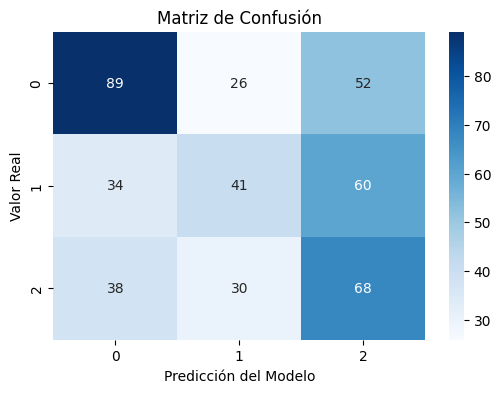

In [15]:
labels_target = sorted(pd.Series(y_test_tch).unique())

cm = confusion_matrix(y_test_tch, y_pred_clf, labels=labels_target)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_target,
    yticklabels=labels_target
)
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

### Importancia de variable

      Variable  Importancia
3       cortes     0.225457
2         edad     0.128215
5        vejez     0.125733
6      lluvias     0.112281
7  pct_diatrea     0.108141
0     dosismad     0.107296
1      semsmad     0.098396
4           me     0.094481


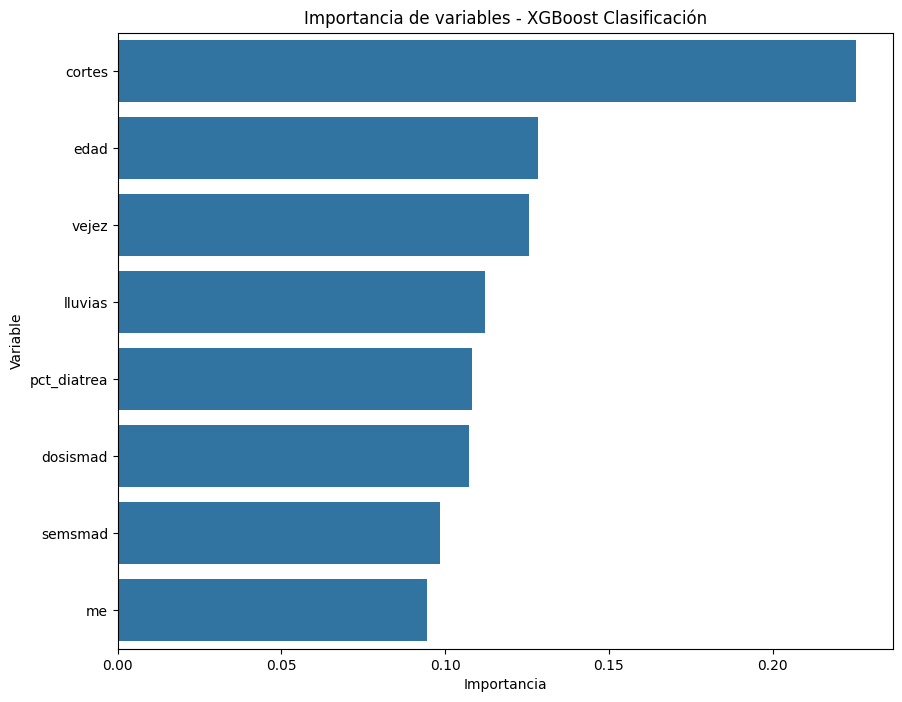

In [16]:
best_model_clf = grid_search_clf.best_estimator_
# Importancia de variables
importancias_clf = pd.DataFrame({
    'Variable': X_train_tch.columns,
    'Importancia': best_model_clf.feature_importances_
})

# Ordenar de mayor a menor
importancias_clf = importancias_clf.sort_values(by='Importancia', ascending=False)

print(importancias_clf)

plt.figure(figsize=(10, 8))
sns.barplot(data=importancias_clf, x='Importancia', y='Variable')
plt.title('Importancia de variables - XGBoost Clasificación')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

## XGBoost utilziando el dataset de clasificacion de sacarosa 

### Division de variables predictoras y objetivo

In [17]:
X_clf_sac = df_clf_sac.drop(columns=['Clase_Sacarosa'], errors='ignore')
y_clf_sac = df_clf_sac['Clase_Sacarosa']

X_train_sac, X_test_sac, y_train_sac, y_test_sac = train_test_split(
    X_clf_sac, y_clf_sac,
    test_size=0.2,
    random_state=42
)

print("X_train_sac:", X_train_sac.shape)
print("X_test_sac :", X_test_sac.shape)
print("y_train_sac:", y_train_sac.shape)
print("y_test_sac :", y_test_sac.shape)

X_train_sac: (1749, 8)
X_test_sac : (438, 8)
y_train_sac: (1749,)
y_test_sac : (438,)


### Validacion cruzada y busqueda de hiperparametros

In [18]:
xgb_base_clf_sac = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

# Validación cruzada estratificada
cv_clf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Espacio de hiperparámetros
param_grid_clf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Búsqueda con validación cruzada
grid_search_clf = GridSearchCV(
    estimator=xgb_base_clf_sac,
    param_grid=param_grid_clf,
    cv=cv_clf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_clf.fit(X_train_sac, y_train_sac)

print("Mejores parámetros:")
print(grid_search_clf.best_params_)

print("\nMejor score CV:")
print(grid_search_clf.best_score_)

Fitting 10 folds for each of 243 candidates, totalling 2430 fits
Mejores parámetros:
{'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

Mejor score CV:
0.4991430887596354


In [19]:
# Predicciones
y_pred_clf_sac = grid_search_clf.best_estimator_.predict(X_test_sac)

# Métricas
accuracy = accuracy_score(y_test_sac, y_pred_clf_sac)
recall_macro = recall_score(y_test_sac, y_pred_clf_sac, average='macro')
f1_macro = f1_score(y_test_sac, y_pred_clf_sac, average='macro')
kappa = cohen_kappa_score(y_test_sac, y_pred_clf_sac)

print('--- REPORTE DE RESULTADOS ---')
print(f'Accuracy         : {accuracy:.4f}')
print(f'Recall (Macro)   : {recall_macro:.4f}')
print(f'F1-Score (Macro) : {f1_macro:.4f}')
print(f"Cohen's Kappa    : {kappa:.4f}")

print('\n--- Classification Report ---')
print(classification_report(y_test_sac, y_pred_clf_sac))

--- REPORTE DE RESULTADOS ---
Accuracy         : 0.5023
Recall (Macro)   : 0.4981
F1-Score (Macro) : 0.4902
Cohen's Kappa    : 0.2511

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.54      0.55      0.54       156
           1       0.55      0.65      0.59       144
           2       0.38      0.30      0.33       138

    accuracy                           0.50       438
   macro avg       0.49      0.50      0.49       438
weighted avg       0.49      0.50      0.49       438



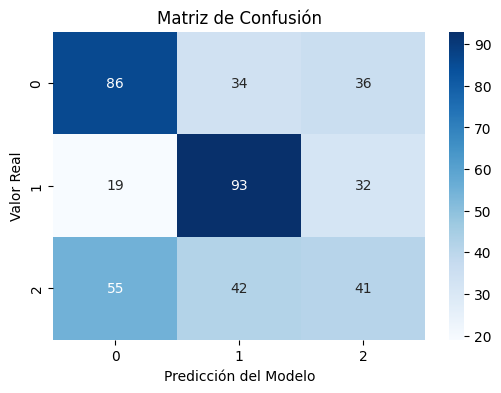

In [21]:
labels_target = sorted(pd.Series(y_test_sac).unique())

cm = confusion_matrix(y_test_sac, y_pred_clf_sac, labels=labels_target)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_target,
    yticklabels=labels_target
)
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

### IMportancia de variables

      Variable  Importancia
6      lluvias     0.167115
4           me     0.142166
1      semsmad     0.133800
7  pct_diatrea     0.117703
5        vejez     0.117472
2         edad     0.112358
0     dosismad     0.107999
3       cortes     0.101386


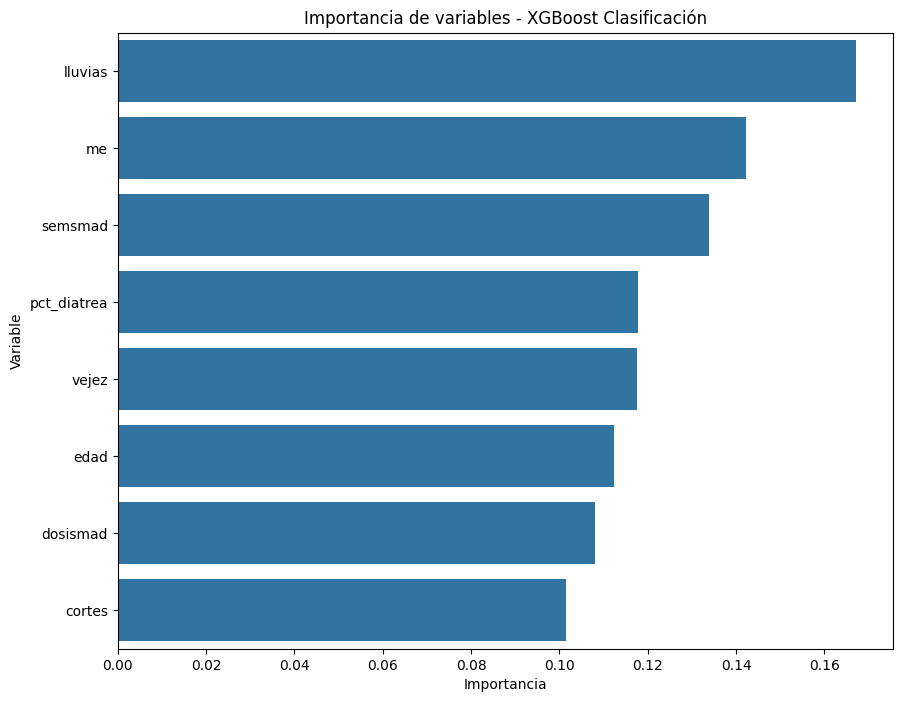

In [20]:
best_model_clf_sac = grid_search_clf.best_estimator_
# Importancia de variables
importancias_clf = pd.DataFrame({
    'Variable': X_train_sac.columns,
    'Importancia': best_model_clf_sac.feature_importances_
})

# Ordenar de mayor a menor
importancias_clf = importancias_clf.sort_values(by='Importancia', ascending=False)

print(importancias_clf)

plt.figure(figsize=(10, 8))
sns.barplot(data=importancias_clf, x='Importancia', y='Variable')
plt.title('Importancia de variables - XGBoost Clasificación')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()